# Capstone Session 9

This notebook is generated from the copied `Capstone_Session_9.pdf` directions and the staged `Churn_Modeling.csv` dataset.

## Objective

Build the required artificial neural network for customer churn prediction, evaluate it on the held-out test set, and score the specified sample customer.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.keras.utils.set_random_seed(42)

BASE_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 9''')
DATASET_PATH = BASE_DIR / 'Churn_Modeling.csv'
OUTPUTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 9/outputs''')
PLOTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 9/outputs/plots''')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv(DATASET_PATH)
display(df.head())
print('Shape:', df.shape)
print('Target distribution:', df['Exited'].value_counts().to_dict())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Shape: (10000, 14)
Target distribution: {0: 7963, 1: 2037}


In [3]:
working_df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).copy()
X = working_df.drop(columns=['Exited'])
y = working_df['Exited']
categorical_columns = ['Geography', 'Gender']
numeric_columns = [column for column in X.columns if column not in categorical_columns]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_columns),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print('Processed train shape:', X_train_processed.shape)
print('Processed test shape:', X_test_processed.shape)

Processed train shape: (8000, 13)
Processed test shape: (2000, 13)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_processed.shape[1],)),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train_processed,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=0,
)
pd.DataFrame(history.history).head()

,accuracy,loss,val_accuracy,val_loss
0,0.693125,0.586485,0.798125,0.441353
1,0.797500,0.443541,0.810625,0.411083
2,0.812656,0.421831,0.824375,0.396646
3,0.822656,0.406891,0.828125,0.385007
4,0.830625,0.393772,0.838125,0.374242


In [5]:
test_probabilities = model.predict(X_test_processed, verbose=0).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)
test_accuracy = float(accuracy_score(y_test, test_predictions))
test_confusion = confusion_matrix(y_test, test_predictions)
print('Test accuracy:', round(test_accuracy, 4))
print('Confusion matrix:', test_confusion.tolist())

Test accuracy: 0.8545
Confusion matrix: [[1552, 41], [250, 157]]


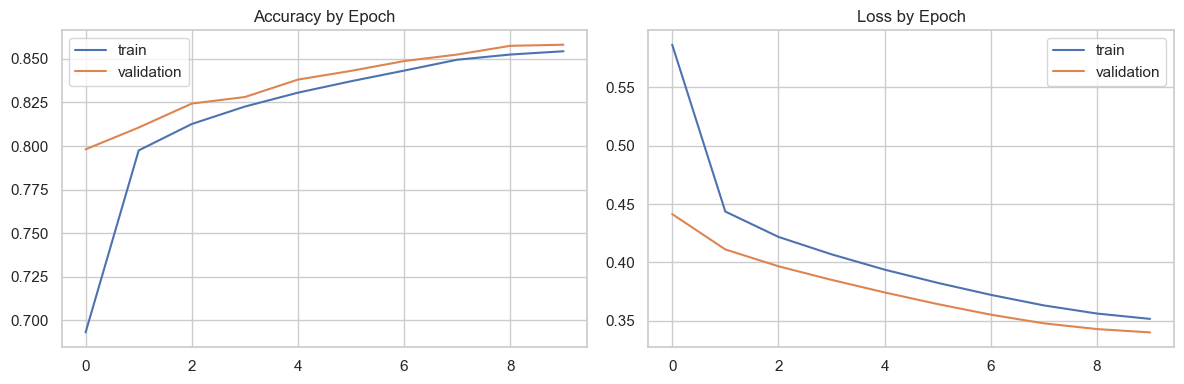

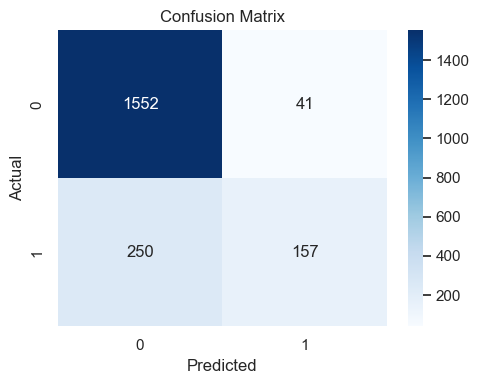

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy by Epoch')
axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss by Epoch')
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'training_history.png', dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()
plt.close(fig)

In [7]:
sample_customer = pd.DataFrame([{
    'CreditScore': 600,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000,
}])
sample_processed = preprocessor.transform(sample_customer)
sample_probability = float(model.predict(sample_processed, verbose=0).ravel()[0])
sample_prediction = int(sample_probability >= 0.5)
sample_decision = 'Do not allow to go' if sample_prediction == 1 else 'Allow to stay'
{
    'sample_probability': round(sample_probability, 4),
    'sample_prediction': sample_prediction,
    'sample_decision': sample_decision,
}

{'sample_probability': 0.038,
 'sample_prediction': 0,
 'sample_decision': 'Allow to stay'}

In [8]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUTS_DIR / 'session_9_training_history.csv', index=False)
prediction_frame = pd.DataFrame({
    'actual': y_test.reset_index(drop=True),
    'predicted_probability': test_probabilities,
    'predicted_label': test_predictions,
})
prediction_frame.head(100).to_csv(OUTPUTS_DIR / 'session_9_prediction_samples.csv', index=False)
summary = {
    'dataset_shape': list(df.shape),
    'target_distribution': df['Exited'].value_counts().to_dict(),
    'processed_feature_count': int(X_train_processed.shape[1]),
    'test_accuracy': test_accuracy,
    'confusion_matrix': test_confusion.tolist(),
    'sample_customer_probability': sample_probability,
    'sample_customer_prediction': sample_prediction,
    'sample_customer_decision': sample_decision,
}
with open(OUTPUTS_DIR / 'session_9_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'dataset_shape': [10000, 14],
 'target_distribution': {0: 7963, 1: 2037},
 'processed_feature_count': 13,
 'test_accuracy': 0.8545,
 'confusion_matrix': [[1552, 41], [250, 157]],
 'sample_customer_probability': 0.03795744478702545,
 'sample_customer_prediction': 0,
 'sample_customer_decision': 'Allow to stay'}